**© Copyright AIDENTIFY. All rights reserved.**

# Part 4 | Session 30: 그래프 RAG - 지식 그래프 기반 검색 증강

## 학습 목표

1️⃣ 벡터 RAG의 한계를 이해하고 그래프 RAG의 필요성을 파악한다  
2️⃣ 지식 그래프의 기본 개념 (노드, 엣지, 트리플)을 학습한다  
3️⃣ Graph RAG 파이프라인의 전체 흐름을 이해한다  
4️⃣ Neo4j를 활용한 그래프 RAG를 직접 구축한다  
5️⃣ LangChain GraphRAG 연동을 실습한다  

---

### 실습 환경
- **GPU**: 선택사항
- **필수 패키지**: langchain, neo4j, networkx, openai
- **외부 서비스**: Neo4j (Docker 또는 Neo4j Aura 무료 인스턴스)

In [1]:
# 💡 setup.sh 실행했으면 이 셀은 건너뛰세요 (참고용 — 본 노트북이 필요로 하는 패키지)
# 패키지 설치
# !pip install -q langchain langchain-community langchain-openai neo4j networkx matplotlib openai tiktoken

In [2]:
# 패키지 임포트 및 환경 설정
import os
import json
import networkx as nx
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple
from dotenv import load_dotenv, find_dotenv

# .env 로드 — OPENAI_API_KEY / NEO4J_* 를 환경변수로 (상위 폴더까지 탐색)
load_dotenv(find_dotenv(usecwd=True))

_have = lambda k: "✅" if os.environ.get(k) else "❌(미설정)"
print("패키지 로드 완료")
print(f"  OPENAI_API_KEY: {_have('OPENAI_API_KEY')}   NEO4J_URI: {_have('NEO4J_URI')}")

패키지 로드 완료
  OPENAI_API_KEY: ✅   NEO4J_URI: ✅


---

## 1️⃣ 벡터 RAG의 한계

벡터 RAG는 문서를 벡터로 변환하여 유사도 기반 검색을 수행합니다.  
하지만 다음과 같은 구조적 한계가 존재합니다.

### 관계 정보 손실

벡터 임베딩은 텍스트의 **의미적 유사성**은 포착하지만, 엔티티 간 **명시적 관계**는 손실됩니다.

```
예시: "삼성전자의 CEO는 이재용이다" + "이재용은 서울대를 졸업했다"

벡터 RAG: 두 문장을 독립적인 청크로 저장 → 관계 연결 불가
그래프 RAG: 삼성전자 --[CEO]--> 이재용 --[졸업]--> 서울대 → 관계 추론 가능
```

### 멀티홉 추론의 어려움

| 질문 유형 | 벡터 RAG | 그래프 RAG |
|-----------|----------|------------|
| 단순 사실 질문 | ✅ 우수 | ✅ 우수 |
| 관계 기반 질문 | ❌ 한계 | ✅ 우수 |
| 멀티홉 추론 | ❌ 매우 어려움 | ✅ 자연스러움 |
| 글로벌 요약 | ❌ 한계 | ✅ 커뮤니티 요약 |

In [3]:
# §1 의 핵심 도전 — 멀티홉 추론을 벡터 RAG는 왜 못 풀까?
#
# 우리의 실습 데이터: part4/data/companies.txt
#   ─ 그룹 3개 (삼성·SK·현대자동차)
#   ─ 그룹마다 회장 1명, 계열사 3개, 각 계열사 CEO 1명
#   ─ 임원 12명의 졸업 학교

print("=" * 60)
print("[멀티홉 도전 질문]")
print("=" * 60)
print()
print("Q.  이재용이 회장인 그룹의 모든 계열사 CEO 들이")
print("    어느 학교를 나왔는가?")
print()
print("필요한 추론 경로 (4-hop):")
print("    이재용   ──[HAS_CHAIRMAN⁻¹]──→  ? 그룹")
print("    ? 그룹    ←─[SUBSIDIARY_OF]───   ? 계열사")
print("    ? 계열사  ──[HAS_CEO]─────────→  ? CEO")
print("    ? CEO    ──[GRADUATED_FROM]──→  ? 학교")
print()
print("=" * 60)
print("[벡터 RAG로 풀기 어려운 이유]")
print("=" * 60)
print("  ① 4개의 서로 다른 문장이 모두 필요하다")
print("  ② 임베딩 유사도는 '이재용' 만 매칭하고 멈춘다")
print("  ③ 중간 단계 단어('그룹', '계열사')가 질문에 등장하지 않는다")
print("  ④ Top-K 검색은 한 번에 1-hop 만 펼쳐준다")
print()
print("→ §3 에서 같은 질문을 그래프 RAG 로 자연스럽게 푸는 흐름을 봅니다.")


[멀티홉 도전 질문]

Q.  이재용이 회장인 그룹의 모든 계열사 CEO 들이
    어느 학교를 나왔는가?

필요한 추론 경로 (4-hop):
    이재용   ──[HAS_CHAIRMAN⁻¹]──→  ? 그룹
    ? 그룹    ←─[SUBSIDIARY_OF]───   ? 계열사
    ? 계열사  ──[HAS_CEO]─────────→  ? CEO
    ? CEO    ──[GRADUATED_FROM]──→  ? 학교

[벡터 RAG로 풀기 어려운 이유]
  ① 4개의 서로 다른 문장이 모두 필요하다
  ② 임베딩 유사도는 '이재용' 만 매칭하고 멈춘다
  ③ 중간 단계 단어('그룹', '계열사')가 질문에 등장하지 않는다
  ④ Top-K 검색은 한 번에 1-hop 만 펼쳐준다

→ §3 에서 같은 질문을 그래프 RAG 로 자연스럽게 푸는 흐름을 봅니다.


---

## 2️⃣ 지식 그래프 개요

### 기본 구성 요소

지식 그래프는 세 가지 핵심 요소로 구성됩니다:

- **노드 (Node)**: 엔티티를 나타냄 (사람, 조직, 장소 등)
- **엣지 (Edge)**: 노드 간의 관계를 나타냄 (소속, 위치, 생산 등)
- **트리플 (Triple)**: Subject - Predicate - Object 형태의 기본 단위

```
트리플 예시:
  (삼성전자, CEO, 이재용)
  (이재용, 졸업, 서울대학교)
  (서울대학교, 위치, 서울시 관악구)
```

### 지식 그래프 vs 일반 그래프

| 특성 | 일반 그래프 | 지식 그래프 |
|------|------------|------------|
| 노드 | 단순 식별자 | 타입이 있는 엔티티 |
| 엣지 | 단순 연결 | 의미 있는 관계 (레이블) |
| 속성 | 제한적 | 풍부한 프로퍼티 |
| 스키마 | 없음 | 온톨로지 기반 |

/tmp/ipykernel_43047/1712915646.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


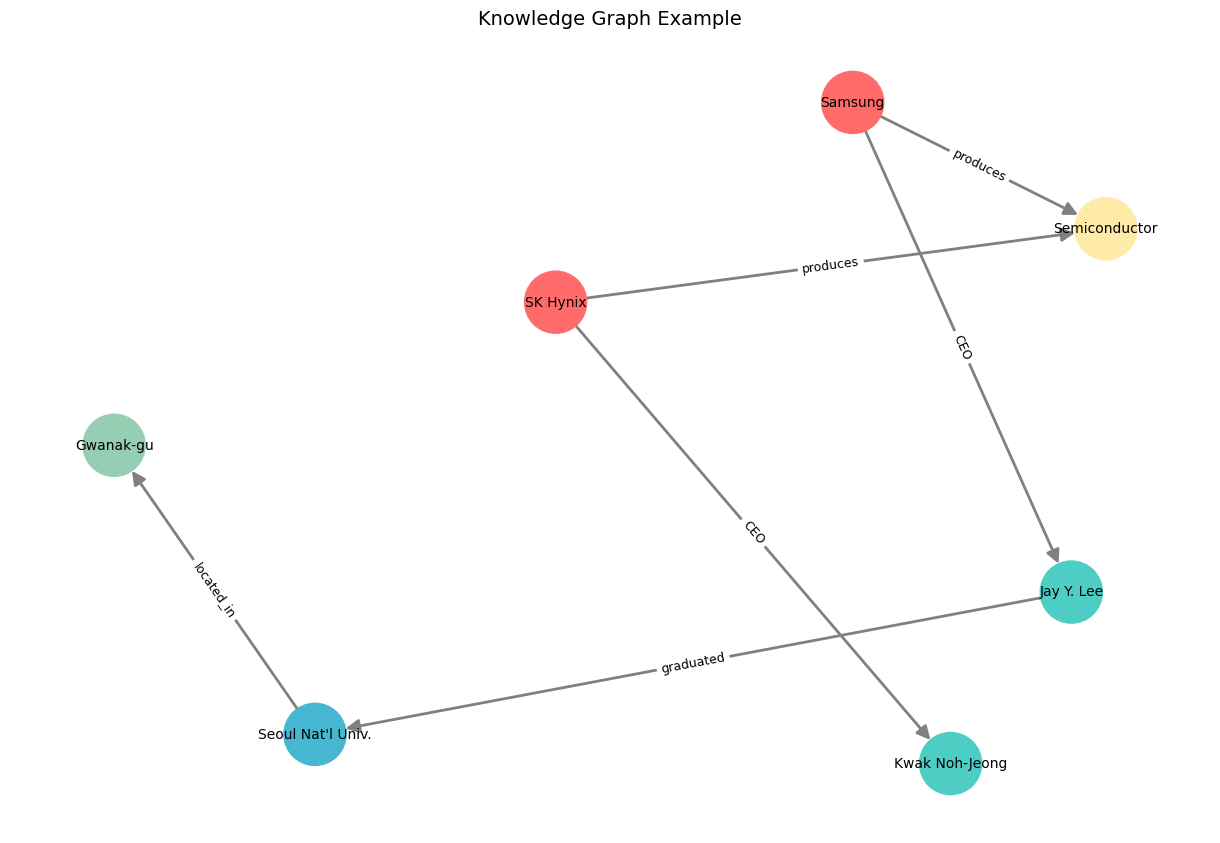


Nodes: 7
Edges: 6
Triples:
  (Samsung, CEO, Jay Y. Lee)
  (Jay Y. Lee, graduated, Seoul Nat'l Univ.)
  (Seoul Nat'l Univ., located_in, Gwanak-gu)
  (Samsung, produces, Semiconductor)
  (SK Hynix, CEO, Kwak Noh-Jeong)
  (SK Hynix, produces, Semiconductor)


In [4]:
# NetworkX visualization of a small knowledge graph

G = nx.DiGraph()

# Nodes (entities)
entities = {
    "Samsung": "Company",
    "Jay Y. Lee": "Person",
    "Seoul Nat'l Univ.": "University",
    "Gwanak-gu": "Region",
    "Semiconductor": "Product",
    "SK Hynix": "Company",
    "Kwak Noh-Jeong": "Person",
}

for entity, etype in entities.items():
    G.add_node(entity, type=etype)

# Edges (relations = triples)
triples = [
    ("Samsung", "Jay Y. Lee", "CEO"),
    ("Jay Y. Lee", "Seoul Nat'l Univ.", "graduated"),
    ("Seoul Nat'l Univ.", "Gwanak-gu", "located_in"),
    ("Samsung", "Semiconductor", "produces"),
    ("SK Hynix", "Kwak Noh-Jeong", "CEO"),
    ("SK Hynix", "Semiconductor", "produces"),
]

for subj, obj, pred in triples:
    G.add_edge(subj, obj, relation=pred)

# Visualization
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=2, seed=42)

# Node-type colors
color_map = {"Company": "#FF6B6B", "Person": "#4ECDC4", "University": "#45B7D1", "Region": "#96CEB4", "Product": "#FFEAA7"}
node_colors = [color_map.get(entities.get(n, ""), "#DDA0DD") for n in G.nodes()]

nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=2000,
        font_size=10, arrows=True, arrowsize=20,
        edge_color="gray", width=2)

# Edge labels
edge_labels = {(u, v): d["relation"] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

plt.title("Knowledge Graph Example", fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nNodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Triples:")
for subj, obj, pred in triples:
    print(f"  ({subj}, {pred}, {obj})")

---

## 3️⃣ Graph RAG 파이프라인

Graph RAG의 전체 파이프라인은 다음과 같습니다:

```
┌─────────────┐    ┌──────────────────┐    ┌─────────────┐    ┌──────────────┐    ┌──────────────┐
│   문서 입력   │ →  │ 엔티티/관계 추출  │ →  │ 그래프 구축  │ →  │  그래프 검색   │ →  │  LLM 생성    │
└─────────────┘    └──────────────────┘    └─────────────┘    └──────────────┘    └──────────────┘
```

### 각 단계 상세

1. **문서 입력**: 원본 텍스트 문서를 청크 단위로 분할
2. **엔티티/관계 추출**: LLM을 사용하여 텍스트에서 엔티티와 관계를 추출
3. **그래프 구축**: 추출된 트리플을 그래프 데이터베이스에 저장
4. **그래프 검색**: 사용자 질문을 기반으로 관련 서브그래프 검색
5. **LLM 생성**: 검색된 그래프 컨텍스트를 기반으로 최종 답변 생성

In [5]:
# Step 1 & 2: 텍스트 → LLM 엔티티/관계 추출
from pathlib import Path
from openai import OpenAI

DATA_PATH = Path("data/companies.txt")
raw_text = DATA_PATH.read_text(encoding="utf-8")

# 주석/공백 제거
sentences = [s.strip() for s in raw_text.splitlines()
             if s.strip() and not s.startswith("#")]
print(f"문장 수: {len(sentences)}")
print("샘플:")
for s in sentences[:3]:
    print(f"  • {s}")
print()


EXTRACTION_PROMPT = """다음 한국어 텍스트에서 엔티티와 관계를 추출해 JSON 으로 반환하세요.

관계 타입(정확히 이 4가지만 사용):
  - HAS_CHAIRMAN   : 그룹의 회장
  - SUBSIDIARY_OF  : 계열사가 어느 그룹 소속인지
  - HAS_CEO        : 계열사의 CEO
  - GRADUATED_FROM : 인물이 졸업한 학교

엔티티 타입: 그룹, 계열사, 인물, 학교

⚠ 중요 규칙 (반드시 지킬 것):
1. 엔티티 이름(name)에 한국어 조사(은/는/이/가/을/를/의/에/와/과/도/로 등)를 절대 포함하지 마세요.
   예) "삼성전자의" → "삼성전자",  "삼성전자는" → "삼성전자"
2. relations 의 subject/object 는 entities 의 name 과 글자까지 완전히 동일해야 합니다.
3. 텍스트에 나오는 학교도 빠짐없이 entities 에 "학교" 타입으로 포함하세요.

형식:
{{
  "entities": [{{"name": "...", "type": "..."}}],
  "relations": [{{"subject": "...", "predicate": "...", "object": "..."}}]
}}

텍스트:
{text}
"""


def extract_with_llm(text: str) -> dict:
    """LLM 호출. API 키 없거나 실패 시 미리 준비한 MOCK_RESULT 사용."""
    try:
        client = OpenAI()
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system",
                 "content": "당신은 정확한 한국어 지식 그래프 추출기입니다."},
                {"role": "user", "content": EXTRACTION_PROMPT.format(text=text)},
            ],
            temperature=0,
            response_format={"type": "json_object"},
        )
        return json.loads(response.choices[0].message.content)
    except Exception as e:
        print(f"⚠ LLM 호출 실패 → MOCK_RESULT 사용 ({type(e).__name__})")
        return MOCK_RESULT


# ── 강의 진행용 MOCK 결과 (API 키 없어도 실습 가능) ─────────
MOCK_RESULT = {
    "entities": [
        # 그룹
        {"name": "삼성그룹", "type": "그룹"},
        {"name": "SK그룹", "type": "그룹"},
        {"name": "현대자동차그룹", "type": "그룹"},
        # 회장
        {"name": "이재용", "type": "인물"}, {"name": "최태원", "type": "인물"},
        {"name": "정의선", "type": "인물"},
        # 계열사
        {"name": "삼성전자", "type": "계열사"}, {"name": "삼성물산", "type": "계열사"},
        {"name": "삼성SDS", "type": "계열사"}, {"name": "SK하이닉스", "type": "계열사"},
        {"name": "SK이노베이션", "type": "계열사"}, {"name": "SK텔레콤", "type": "계열사"},
        {"name": "현대자동차", "type": "계열사"}, {"name": "기아", "type": "계열사"},
        {"name": "현대모비스", "type": "계열사"},
        # CEO
        {"name": "한종희", "type": "인물"}, {"name": "오세철", "type": "인물"},
        {"name": "이준희", "type": "인물"}, {"name": "곽노정", "type": "인물"},
        {"name": "박상규", "type": "인물"}, {"name": "유영상", "type": "인물"},
        {"name": "장재훈", "type": "인물"}, {"name": "송호성", "type": "인물"},
        {"name": "이규석", "type": "인물"},
        # 학교
        {"name": "서울대학교", "type": "학교"}, {"name": "인하대학교", "type": "학교"},
        {"name": "연세대학교", "type": "학교"}, {"name": "시카고대학교", "type": "학교"},
        {"name": "고려대학교", "type": "학교"}, {"name": "한양대학교", "type": "학교"},
    ],
    "relations": [
        # 그룹 → 회장
        {"subject": "삼성그룹", "predicate": "HAS_CHAIRMAN", "object": "이재용"},
        {"subject": "SK그룹", "predicate": "HAS_CHAIRMAN", "object": "최태원"},
        {"subject": "현대자동차그룹", "predicate": "HAS_CHAIRMAN", "object": "정의선"},
        # 계열사 → 그룹
        {"subject": "삼성전자", "predicate": "SUBSIDIARY_OF", "object": "삼성그룹"},
        {"subject": "삼성물산", "predicate": "SUBSIDIARY_OF", "object": "삼성그룹"},
        {"subject": "삼성SDS", "predicate": "SUBSIDIARY_OF", "object": "삼성그룹"},
        {"subject": "SK하이닉스", "predicate": "SUBSIDIARY_OF", "object": "SK그룹"},
        {"subject": "SK이노베이션", "predicate": "SUBSIDIARY_OF", "object": "SK그룹"},
        {"subject": "SK텔레콤", "predicate": "SUBSIDIARY_OF", "object": "SK그룹"},
        {"subject": "현대자동차", "predicate": "SUBSIDIARY_OF", "object": "현대자동차그룹"},
        {"subject": "기아", "predicate": "SUBSIDIARY_OF", "object": "현대자동차그룹"},
        {"subject": "현대모비스", "predicate": "SUBSIDIARY_OF", "object": "현대자동차그룹"},
        # 계열사 → CEO
        {"subject": "삼성전자", "predicate": "HAS_CEO", "object": "한종희"},
        {"subject": "삼성물산", "predicate": "HAS_CEO", "object": "오세철"},
        {"subject": "삼성SDS", "predicate": "HAS_CEO", "object": "이준희"},
        {"subject": "SK하이닉스", "predicate": "HAS_CEO", "object": "곽노정"},
        {"subject": "SK이노베이션", "predicate": "HAS_CEO", "object": "박상규"},
        {"subject": "SK텔레콤", "predicate": "HAS_CEO", "object": "유영상"},
        {"subject": "현대자동차", "predicate": "HAS_CEO", "object": "장재훈"},
        {"subject": "기아", "predicate": "HAS_CEO", "object": "송호성"},
        {"subject": "현대모비스", "predicate": "HAS_CEO", "object": "이규석"},
        # 인물 → 학교
        {"subject": "이재용", "predicate": "GRADUATED_FROM", "object": "서울대학교"},
        {"subject": "최태원", "predicate": "GRADUATED_FROM", "object": "시카고대학교"},
        {"subject": "정의선", "predicate": "GRADUATED_FROM", "object": "고려대학교"},
        {"subject": "한종희", "predicate": "GRADUATED_FROM", "object": "인하대학교"},
        {"subject": "오세철", "predicate": "GRADUATED_FROM", "object": "서울대학교"},
        {"subject": "이준희", "predicate": "GRADUATED_FROM", "object": "연세대학교"},
        {"subject": "곽노정", "predicate": "GRADUATED_FROM", "object": "서울대학교"},
        {"subject": "박상규", "predicate": "GRADUATED_FROM", "object": "서울대학교"},
        {"subject": "유영상", "predicate": "GRADUATED_FROM", "object": "서울대학교"},
        {"subject": "장재훈", "predicate": "GRADUATED_FROM", "object": "서울대학교"},
        {"subject": "송호성", "predicate": "GRADUATED_FROM", "object": "한양대학교"},
        {"subject": "이규석", "predicate": "GRADUATED_FROM", "object": "서울대학교"},
    ],
}


# 실행 (LLM 또는 mock)
result = extract_with_llm(raw_text)

# 타입별 카운트
from collections import Counter
ent_types = Counter(e["type"] for e in result["entities"])
rel_types = Counter(r["predicate"] for r in result["relations"])

print(f"엔티티 {len(result['entities'])}개:  " +
      ",  ".join(f"{t} {n}" for t, n in ent_types.most_common()))
print(f"관계   {len(result['relations'])}개:  " +
      ",  ".join(f"{t} {n}" for t, n in rel_types.most_common()))


문장 수: 33
샘플:
  • 삼성그룹은 이재용이 회장으로 이끌고 있다.
  • 이재용은 서울대학교를 졸업했다.
  • 삼성전자는 삼성그룹의 계열사이다.

엔티티 29개:  인물 12,  계열사 9,  학교 5,  그룹 3
관계   33개:  GRADUATED_FROM 12,  SUBSIDIARY_OF 9,  HAS_CEO 9,  HAS_CHAIRMAN 3


In [6]:
# Step 3: 추출 결과 → NetworkX 지식 그래프 구축

def build_knowledge_graph(extraction_result: Dict) -> nx.DiGraph:
    """엔티티/관계 dict → DiGraph."""
    G = nx.DiGraph()
    for entity in extraction_result["entities"]:
        G.add_node(entity["name"], type=entity["type"])
    for relation in extraction_result["relations"]:
        G.add_edge(
            relation["subject"], relation["object"],
            relation=relation["predicate"],
        )
    return G


kg = build_knowledge_graph(result)
print(f"지식 그래프 구축 완료")
print(f"  노드: {kg.number_of_nodes()}개   엣지: {kg.number_of_edges()}개")

# 타입별 노드 확인
from collections import defaultdict
by_type = defaultdict(list)
for n, d in kg.nodes(data=True):
    by_type[d.get("type", "?")].append(n)

print("\n노드 (타입별):")
for t in ["그룹", "계열사", "인물", "학교"]:
    print(f"  [{t}] ({len(by_type[t])}개)  " + ", ".join(by_type[t]))

# 관계 타입별 엣지 수
rel_counts = Counter(d["relation"] for _, _, d in kg.edges(data=True))
print("\n엣지 (관계별):")
for rel, n in rel_counts.most_common():
    print(f"  [{rel}]  {n}개")


지식 그래프 구축 완료
  노드: 30개   엣지: 33개

노드 (타입별):
  [그룹] (3개)  삼성그룹, SK그룹, 현대자동차그룹
  [계열사] (9개)  삼성전자, 삼성물산, 삼성SDS, SK하이닉스, SK이노베이션, SK텔레콤, 현대자동차, 기아, 현대모비스
  [인물] (12개)  이재용, 한종희, 오세철, 이준희, 최태원, 곽노정, 박상규, 유영상, 정의선, 장재훈, 송호성, 이규석
  [학교] (5개)  서울대학교, 인하대학교, 연세대학교, 시카고대학교, 고려대학교

엣지 (관계별):
  [GRADUATED_FROM]  12개
  [SUBSIDIARY_OF]  9개
  [HAS_CEO]  9개
  [HAS_CHAIRMAN]  3개


In [7]:
# Step 4: 멀티홉 그래프 검색 — §1 의 4-hop 도전 질문을 해결

def multihop_path(G: nx.DiGraph, start: str, edge_chain: List[tuple]) -> List[Dict]:
    """관계 타입 체인을 따라 다단 경로 탐색.

    edge_chain = [(relation_name, direction), ...]
        direction = "out"  →  현재 노드에서 나가는 엣지
        direction = "in"   →  현재 노드로 들어오는 엣지
    """
    frontier = [{"node": start, "path": [start], "rels": []}]
    for rel, direction in edge_chain:
        next_frontier = []
        for f in frontier:
            cur = f["node"]
            if direction == "out":
                edges = [(cur, t, d) for _, t, d in G.out_edges(cur, data=True)]
            else:
                edges = [(s, cur, d) for s, _, d in G.in_edges(cur, data=True)]
            for s, t, d in edges:
                if d["relation"] == rel:
                    nxt = t if direction == "out" else s
                    next_frontier.append({
                        "node": nxt,
                        "path": f["path"] + [nxt],
                        "rels": f["rels"] + [(s, rel, t)],
                    })
        frontier = next_frontier
    return frontier


# §1 의 도전 질문: "이재용이 회장인 그룹의 모든 계열사 CEO 들이 어느 학교를 나왔는가?"
# 추론 체인 (이재용 시작):
#   1) 이재용 ←HAS_CHAIRMAN─ 그룹            (in)
#   2) 그룹 ←SUBSIDIARY_OF─ 계열사          (in)
#   3) 계열사 ─HAS_CEO→ CEO                 (out)
#   4) CEO ─GRADUATED_FROM→ 학교            (out)
START_NODE = "이재용"
EDGE_CHAIN = [
    ("HAS_CHAIRMAN",   "in"),
    ("SUBSIDIARY_OF",  "in"),
    ("HAS_CEO",        "out"),
    ("GRADUATED_FROM", "out"),
]

results = multihop_path(kg, START_NODE, EDGE_CHAIN)

# LLM 추출이 불완전하면 4-hop 체인이 끊겨 경로가 0개가 될 수 있다.
# (시작 노드명 불일치 / 관계 타입 누락 / hop 간 엔티티명 불일치 등)
# 강의 재현성을 위해 이 경우 결정적 MOCK_RESULT 로 폴백한다.
if not results:
    print(f"⚠ LLM 추출 결과로는 '{START_NODE}' 시작 4-hop 경로를 찾지 못했습니다.")
    print("  → 결정적 MOCK_RESULT 로 그래프를 다시 구축해 진행합니다.\n")
    kg = build_knowledge_graph(MOCK_RESULT)
    results = multihop_path(kg, START_NODE, EDGE_CHAIN)

print(f"=== 4-hop 검색 결과 — {len(results)}개 경로 ===\n")
for r in results:
    chain = " → ".join(r["path"])
    print(f"  {chain}")

print()
print("관계까지 명시한 트리플 형태:")
for r in results[:3]:
    for s, rel, t in r["rels"]:
        print(f"    ({s}) --[{rel}]--> ({t})")
    print()

=== 4-hop 검색 결과 — 3개 경로 ===

  이재용 → 삼성그룹 → 삼성전자 → 한종희 → 인하대학교
  이재용 → 삼성그룹 → 삼성물산 → 오세철 → 서울대학교
  이재용 → 삼성그룹 → 삼성SDS → 이준희 → 연세대학교

관계까지 명시한 트리플 형태:
    (삼성그룹) --[HAS_CHAIRMAN]--> (이재용)
    (삼성전자) --[SUBSIDIARY_OF]--> (삼성그룹)
    (삼성전자) --[HAS_CEO]--> (한종희)
    (한종희) --[GRADUATED_FROM]--> (인하대학교)

    (삼성그룹) --[HAS_CHAIRMAN]--> (이재용)
    (삼성물산) --[SUBSIDIARY_OF]--> (삼성그룹)
    (삼성물산) --[HAS_CEO]--> (오세철)
    (오세철) --[GRADUATED_FROM]--> (서울대학교)

    (삼성그룹) --[HAS_CHAIRMAN]--> (이재용)
    (삼성SDS) --[SUBSIDIARY_OF]--> (삼성그룹)
    (삼성SDS) --[HAS_CEO]--> (이준희)
    (이준희) --[GRADUATED_FROM]--> (연세대학교)



In [8]:
# Step 5: 그래프 컨텍스트 → LLM 답변 생성 + 그래프 직접 집계

# 1) 컨텍스트 트리플 (중복 제거)
context_triples_set = set()
for r in results:
    for s, rel, t in r["rels"]:
        context_triples_set.add(f"({s}) --[{rel}]--> ({t})")
context_triples = sorted(context_triples_set)


GRAPH_RAG_PROMPT = """다음 지식 그래프 정보를 참고해 질문에 답하세요.

지식 그래프 컨텍스트:
{context}

질문: {question}

학교별로 그룹화해서 정리해주세요."""


def graph_rag_answer(question: str, triples: List[str]) -> str:
    client = OpenAI()
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user",
                   "content": GRAPH_RAG_PROMPT.format(
                       context="\n".join(triples), question=question)}],
        temperature=0,
    )
    return response.choices[0].message.content


question = ("이재용이 회장인 그룹의 모든 계열사 CEO 들이 "
            "어느 학교를 나왔는지 알려줘.")

print("질문:", question)
print(f"\n컨텍스트로 사용할 트리플 ({len(context_triples)}개):")
for t in context_triples:
    print(f"  {t}")


# 2) LLM 답변 (API 키 있을 때만)
print("\n" + "=" * 60)
print("[LLM 답변]")
print("=" * 60)
try:
    answer = graph_rag_answer(question, context_triples)
    print(answer)
except Exception as e:
    print(f"⚠ LLM 호출 생략 ({type(e).__name__}) — 아래 '그래프 직접 추론' 결과 참고")


# 3) 그래프에서 직접 학교별 그룹화 (LLM 없이도 정확한 답)
print("\n" + "=" * 60)
print("[그래프 직접 추론 — LLM 없이도 결정적]")
print("=" * 60)

by_school = defaultdict(list)
for r in results:
    school  = r["path"][-1]
    ceo     = r["path"][-2]
    company = r["path"][-3]
    by_school[school].append((ceo, company))

for school in sorted(by_school, key=lambda s: -len(by_school[s])):
    members = by_school[school]
    print(f"\n  ▶ {school}  ({len(members)}명)")
    for ceo, company in members:
        print(f"      • {ceo}  ({company} CEO)")

# 한 줄 요약
total_ceos = sum(len(v) for v in by_school.values())
if by_school:
    top_school = max(by_school, key=lambda s: len(by_school[s]))
    print(f"\n→ 삼성그룹 계열사 CEO {total_ceos}명 중 가장 많이 나온 학교: "
          f"{top_school} ({len(by_school[top_school])}명)")
else:
    print("\n⚠ 집계할 4-hop 경로가 없습니다 (results 가 비어 있음).")
    print("  Step 4 셀을 먼저 실행했는지 확인하세요. 그래도 0개면 추출 결과(result)를 점검하세요.")

질문: 이재용이 회장인 그룹의 모든 계열사 CEO 들이 어느 학교를 나왔는지 알려줘.

컨텍스트로 사용할 트리플 (10개):
  (삼성SDS) --[HAS_CEO]--> (이준희)
  (삼성SDS) --[SUBSIDIARY_OF]--> (삼성그룹)
  (삼성그룹) --[HAS_CHAIRMAN]--> (이재용)
  (삼성물산) --[HAS_CEO]--> (오세철)
  (삼성물산) --[SUBSIDIARY_OF]--> (삼성그룹)
  (삼성전자) --[HAS_CEO]--> (한종희)
  (삼성전자) --[SUBSIDIARY_OF]--> (삼성그룹)
  (오세철) --[GRADUATED_FROM]--> (서울대학교)
  (이준희) --[GRADUATED_FROM]--> (연세대학교)
  (한종희) --[GRADUATED_FROM]--> (인하대학교)

[LLM 답변]
이재용이 회장인 삼성그룹의 모든 계열사 CEO와 그들이 졸업한 학교는 다음과 같습니다:

### 서울대학교
- 오세철 (삼성물산 CEO)

### 연세대학교
- 이준희 (삼성SDS CEO)

### 인하대학교
- 한종희 (삼성전자 CEO)

이렇게 각 CEO가 졸업한 학교를 그룹화하여 정리할 수 있습니다.

[그래프 직접 추론 — LLM 없이도 결정적]

  ▶ 인하대학교  (1명)
      • 한종희  (삼성전자 CEO)

  ▶ 서울대학교  (1명)
      • 오세철  (삼성물산 CEO)

  ▶ 연세대학교  (1명)
      • 이준희  (삼성SDS CEO)

→ 삼성그룹 계열사 CEO 3명 중 가장 많이 나온 학교: 인하대학교 (1명)


---

## 4️⃣ Neo4j 기반 그래프 RAG 실습

### Neo4j 소개

Neo4j는 가장 널리 사용되는 그래프 데이터베이스로, **Cypher** 쿼리 언어를 사용합니다.

```
Neo4j 설치 옵션:
1. Docker: docker run -p 7474:7474 -p 7687:7687 neo4j
2. Neo4j Aura: https://neo4j.com/cloud/aura-free/ (무료 클라우드)
3. Neo4j Desktop: 로컬 설치
```

### Cypher 쿼리 기초

```cypher
-- 노드 생성
CREATE (n:Person {name: '이재용', role: 'CEO'})

-- 관계 생성
MATCH (a:Person {name: '이재용'}), (b:Company {name: '삼성전자'})
CREATE (a)-[:WORKS_AT]->(b)

-- 검색
MATCH (p:Person)-[:WORKS_AT]->(c:Company)
WHERE c.name = '삼성전자'
RETURN p.name

-- 멀티홉 쿼리
MATCH (p:Person)-[:WORKS_AT]->(c:Company)-[:PRODUCES]->(prod:Product)
RETURN p.name, c.name, prod.name
```

### 🚀 빠른 시작: Neo4j Aura (무료 클라우드, 설치 불필요)

1. https://neo4j.com/product/auradb/ → **Start Free** → 가입
2. **AuraDB Free** 인스턴스 생성 → 표시되는 **비밀번호/접속정보(.txt) 저장**
3. 프로젝트 루트 `.env` 에 추가:
   ```
   NEO4J_URI=neo4j+s://xxxxx.databases.neo4j.io
   NEO4J_USERNAME=neo4j
   NEO4J_PASSWORD=발급받은비밀번호
   ```
4. 콘솔에서 **Open** → **Neo4j Browser** 가 열림 → 아래 Cypher 실습


In [9]:
# Neo4j 연결 및 지식 그래프 구축

from neo4j import GraphDatabase


class Neo4jKnowledgeGraph:
    """Neo4j 기반 지식 그래프 관리 클래스"""

    def __init__(self, uri: str, username: str, password: str):
        self.driver = GraphDatabase.driver(uri, auth=(username, password))
        self.driver.verify_connectivity()  # 실제 연결 확인 (실패 시 예외)
        print(f"\u2705 Neo4j 연결 성공: {uri}")

    def close(self):
        self.driver.close()

    def clear_graph(self):
        """그래프 초기화"""
        with self.driver.session() as session:
            session.run("MATCH (n) DETACH DELETE n")
        print("그래프 초기화 완료")

    def add_entity(self, name: str, entity_type: str, properties: Dict = None):
        """엔티티(노드) 추가"""
        props = properties or {}
        props["name"] = name
        prop_str = ", ".join([f"{k}: ${k}" for k in props.keys()])
        query = f"MERGE (n:`{entity_type}` {{{prop_str}}})"  # 라벨 백틱(한글 라벨 대응)
        with self.driver.session() as session:
            session.run(query, **props)

    def add_relation(self, subject: str, predicate: str, obj: str):
        """관계(엣지) 추가 — predicate 를 '실제 관계 타입'으로 사용 (예: CEO_OF).

        이렇게 해야 Cypher/AI 자연어 질의가 자연스럽게 동작한다.
        (RELATION 단일 타입 + type 속성 방식은 AI 가 못 알아먹음)
        """
        # 관계 타입은 Cypher 에서 파라미터화가 안 되므로 안전한 식별자로 정제 후 삽입
        rel_type = "".join(c if (c.isalnum() or c == "_") else "_" for c in predicate).upper()
        query = f"""
        MATCH (a {{name: $subject}}), (b {{name: $object}})
        MERGE (a)-[r:{rel_type}]->(b)
        """
        with self.driver.session() as session:
            session.run(query, subject=subject, object=obj)

    def query_subgraph(self, entity_name: str, max_hops: int = 2) -> List[Dict]:
        """특정 엔티티의 서브그래프 검색"""
        query = f"""
        MATCH path = (start {{name: $name}})-[*1..{max_hops}]-(connected)
        RETURN path
        LIMIT 50
        """
        results = []
        with self.driver.session() as session:
            records = session.run(query, name=entity_name)
            for record in records:
                results.append(str(record))
        return results

    def cypher_query(self, query: str, params: Dict = None) -> List[Dict]:
        """커스텀 Cypher 쿼리 실행"""
        with self.driver.session() as session:
            records = session.run(query, **(params or {}))
            return [dict(record) for record in records]


# 사용 예시 (Neo4j 실행 중일 때)
print("Neo4j 지식 그래프 클래스 정의 완료")
print()
print("사용 예시:")
print('  kg = Neo4jKnowledgeGraph("bolt://localhost:7687", "neo4j", "password")')
print('  kg.add_entity("삼성전자", "Company")')
print('  kg.add_entity("이재용", "Person")')
print('  kg.add_relation("이재용", "CEO", "삼성전자")')
print('  results = kg.query_subgraph("삼성전자")')

Neo4j 지식 그래프 클래스 정의 완료

사용 예시:
  kg = Neo4jKnowledgeGraph("bolt://localhost:7687", "neo4j", "password")
  kg.add_entity("삼성전자", "Company")
  kg.add_entity("이재용", "Person")
  kg.add_relation("이재용", "CEO", "삼성전자")
  results = kg.query_subgraph("삼성전자")


In [10]:
# Neo4j 에 지식 그래프 적재 — cell 9 에서 추출한 result (그룹·계열사·CEO·학교) 사용
# .env 에 NEO4J_URI / NEO4J_USERNAME / NEO4J_PASSWORD 필요 (Aura 발급)

def load_to_neo4j(neo4j_kg, data):
    """추출 결과(entities/relations)를 Neo4j 에 적재."""
    neo4j_kg.clear_graph()
    for e in data["entities"]:
        neo4j_kg.add_entity(e["name"], e["type"], e.get("props", {}))
    for r in data["relations"]:
        neo4j_kg.add_relation(r["subject"], r["predicate"], r["object"])
    print(f"적재: 노드 {len(data['entities'])}개, 관계 {len(data['relations'])}개")


import os
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv(usecwd=True))  # 상위 폴더의 .env 까지 탐색

NEO4J_URI = os.environ.get("NEO4J_URI")
NEO4J_USERNAME = os.environ.get("NEO4J_USERNAME", "neo4j")
NEO4J_PASSWORD = os.environ.get("NEO4J_PASSWORD")

if NEO4J_URI and NEO4J_PASSWORD:
    neo4j_kg = Neo4jKnowledgeGraph(NEO4J_URI, NEO4J_USERNAME, NEO4J_PASSWORD)
    load_to_neo4j(neo4j_kg, result)   # ← cell 9 의 추출 결과 그대로 사용
    n = neo4j_kg.cypher_query("MATCH (n) RETURN count(n) AS c")[0]["c"]
    rc = neo4j_kg.cypher_query("MATCH ()-[x]->() RETURN count(x) AS c")[0]["c"]
    print(f"\n✅ Neo4j 적재 완료 — 노드 {n}개, 관계 {rc}개")
else:
    neo4j_kg = None
    print("⚠ NEO4J_URI/PASSWORD 미설정 — Aura 인스턴스 생성 후 .env 에 추가하세요.")
    print("   무료 인스턴스: https://neo4j.com/product/auradb/")

✅ Neo4j 연결 성공: neo4j+s://4016428c.databases.neo4j.io
그래프 초기화 완료
적재: 노드 29개, 관계 33개

✅ Neo4j 적재 완료 — 노드 29개, 관계 32개


### Neo4j Cypher 질의 실습

`result`(그룹·계열사·CEO·학교)가 Neo4j 에 적재됐습니다. 관계 타입:
`HAS_CHAIRMAN`, `SUBSIDIARY_OF`, `HAS_CEO`, `GRADUATED_FROM`.

**Browser(웹 UI)에 붙여넣어 볼 Cypher:**
```cypher
// 전체 그래프 시각화
MATCH (n)-[r]->(m) RETURN n, r, m

// 삼성그룹 계열사의 CEO
MATCH (g {name:'삼성그룹'})<-[:SUBSIDIARY_OF]-(sub)-[:HAS_CEO]->(ceo)
RETURN sub.name AS 계열사, ceo.name AS CEO

// ★ 4-hop: 이재용이 회장인 그룹의 모든 계열사 CEO 들의 출신 학교
MATCH ({name:'이재용'})<-[:HAS_CHAIRMAN]-(grp)<-[:SUBSIDIARY_OF]-(sub)
      -[:HAS_CEO]->(ceo)-[:GRADUATED_FROM]->(school)
RETURN ceo.name AS CEO, school.name AS 학교 ORDER BY 학교
```
**AI 자연어(Ctrl+I):** "이재용이 회장인 그룹의 계열사 CEO들은 어느 학교를 나왔어?"

In [11]:
# Neo4j Cypher 질의 실습 (서버 연결 시에만 동작)
if neo4j_kg:
    print("\u2460 삼성그룹 계열사의 CEO")
    for row in neo4j_kg.cypher_query(
        "MATCH (g {name:'삼성그룹'})<-[:SUBSIDIARY_OF]-(sub)-[:HAS_CEO]->(ceo) "
        "RETURN sub.name AS sub, ceo.name AS ceo"):
        print(f"   {row['sub']} \u2192 {row['ceo']}")

    print("\n\u2461 4-hop: 이재용이 회장인 그룹의 모든 계열사 CEO 들의 출신 학교")
    for row in neo4j_kg.cypher_query(
        "MATCH ({name:'이재용'})<-[:HAS_CHAIRMAN]-(grp)<-[:SUBSIDIARY_OF]-(sub)"
        "-[:HAS_CEO]->(ceo)-[:GRADUATED_FROM]->(school) "
        "RETURN ceo.name AS ceo, school.name AS school ORDER BY school"):
        print(f"   {row['ceo']} \u2192 {row['school']}")

    neo4j_kg.close()
    print("\n\u2705 Cypher 실습 완료 (연결 종료)")
else:
    print("\u26a0 Neo4j 미연결 — 위 셀에서 .env 설정 후 다시 실행하세요.")

① 삼성그룹 계열사의 CEO
   삼성전자 → 한종희
   삼성물산 → 오세철
   삼성SDS → 이준희

② 4-hop: 이재용이 회장인 그룹의 모든 계열사 CEO 들의 출신 학교
   오세철 → 서울대학교
   이준희 → 연세대학교
   한종희 → 인하대학교

✅ Cypher 실습 완료 (연결 종료)


---

## 5️⃣ LangChain GraphRAG 연동

LangChain은 Neo4j와의 통합을 위한 다양한 도구를 제공합니다.

### 주요 컴포넌트

- **Neo4jGraph**: Neo4j 데이터베이스 연결 및 스키마 관리
- **GraphCypherQAChain**: 자연어 질문을 Cypher 쿼리로 변환
- **LLMGraphTransformer**: 텍스트에서 자동으로 그래프 추출

In [15]:
# LangChain Neo4j 통합

from langchain_community.graphs import Neo4jGraph
from langchain.chains import GraphCypherQAChain
from langchain_openai import ChatOpenAI


def setup_langchain_graph_rag():
    """LangChain 기반 Graph RAG를 설정합니다."""

    # Neo4j 연결
    graph = Neo4jGraph(
        url=os.environ.get("NEO4J_URI", "bolt://localhost:7687"),
        username=os.environ.get("NEO4J_USERNAME", "neo4j"),
        password=os.environ.get("NEO4J_PASSWORD", "password")
    )

    # 그래프 스키마 확인
    print("그래프 스키마:")
    print(graph.schema)

    # LLM 설정
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

    # GraphCypherQAChain: 자연어 → Cypher → 결과 → 자연어 답변
    chain = GraphCypherQAChain.from_llm(
        llm=llm,
        graph=graph,
        verbose=True,
        allow_dangerous_requests=True
    )

    return chain


# Neo4j 실행 중일 때 아래 주석을 해제하세요:
chain = setup_langchain_graph_rag()
result = chain.invoke({"query": "삼성전자의 CEO는 누구인가요?"})
print(result)

print("LangChain GraphCypherQAChain 설정 코드 준비 완료")
print()
print("동작 흐름:")
print("  1. 사용자 질문 입력")
print("  2. LLM이 질문을 Cypher 쿼리로 변환")
print("  3. Neo4j에서 Cypher 쿼리 실행")
print("  4. 쿼리 결과를 LLM에 전달")
print("  5. LLM이 자연어 답변 생성")

/tmp/ipykernel_43047/1465021075.py:12: LangChainDeprecationWarning: The class `Neo4jGraph` was deprecated in LangChain 0.3.8 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-neo4j package and should be used instead. To use it run `pip install -U :class:`~langchain-neo4j` and import as `from :class:`~langchain_neo4j import Neo4jGraph``.
  graph = Neo4jGraph(


그래프 스키마:
Node properties:
그룹 {name: STRING}
인물 {name: STRING}
학교 {name: STRING}
계열사 {name: STRING}
Relationship properties:

The relationships:
(:그룹)-[:HAS_CHAIRMAN]->(:인물)
(:인물)-[:GRADUATED_FROM]->(:학교)
(:계열사)-[:SUBSIDIARY_OF]->(:그룹)
(:계열사)-[:HAS_CEO]->(:인물)


> Entering new GraphCypherQAChain chain...
Generated Cypher:
MATCH (c:계열사 {name: '삼성전자'})-[:HAS_CEO]->(p:인물) RETURN p.name
Full Context:
[{'p.name': '한종희'}]

> Finished chain.
{'query': '삼성전자의 CEO는 누구인가요?', 'result': '삼성전자의 CEO는 한종희입니다.'}
LangChain GraphCypherQAChain 설정 코드 준비 완료

동작 흐름:
  1. 사용자 질문 입력
  2. LLM이 질문을 Cypher 쿼리로 변환
  3. Neo4j에서 Cypher 쿼리 실행
  4. 쿼리 결과를 LLM에 전달
  5. LLM이 자연어 답변 생성


In [ ]:
# LLMGraphTransformer: 텍스트에서 자동으로 그래프 추출

from langchain_experimental.graph_transformers import LLMGraphTransformer
from langchain_core.documents import Document


def auto_extract_graph(texts: List[str]):
    """LLMGraphTransformer를 사용하여 텍스트에서 자동으로 그래프를 추출합니다."""
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
    transformer = LLMGraphTransformer(llm=llm)

    documents = [Document(page_content=text) for text in texts]
    graph_documents = transformer.convert_to_graph_documents(documents)

    print(f"\n추출된 그래프 문서: {len(graph_documents)}개")
    for i, doc in enumerate(graph_documents):
        print(f"\n--- 문서 {i+1} ---")
        print(f"  노드: {[str(n) for n in doc.nodes]}")
        print(f"  관계: {[str(r) for r in doc.relationships]}")

    return graph_documents


# 사용 예시
sample_texts = [
    "네이버의 CEO 최수연은 하이퍼클로바X 개발을 주도하고 있다.",
    "카카오는 카카오톡과 카카오맵 등 다양한 서비스를 제공하는 IT 기업이다.",
]

# API 키 설정 후 실행:
graph_docs = auto_extract_graph(sample_texts)

print(graph_docs)

print("LLMGraphTransformer 자동 그래프 추출 코드 준비 완료")
print("\n이 기능은 다음을 자동으로 수행합니다:")
print("  1. 텍스트에서 엔티티 식별")
print("  2. 엔티티 간 관계 추출")
print("  3. 구조화된 그래프 문서 생성")
print("  4. Neo4j에 직접 저장 가능")

LLMGraphTransformer 자동 그래프 추출 코드 준비 완료

이 기능은 다음을 자동으로 수행합니다:
  1. 텍스트에서 엔티티 식별
  2. 엔티티 간 관계 추출
  3. 구조화된 그래프 문서 생성
  4. Neo4j에 직접 저장 가능


---

## 정리

### 핵심 요약

| 항목 | 벡터 RAG | 그래프 RAG |
|------|----------|------------|
| 데이터 구조 | 벡터 임베딩 | 지식 그래프 (트리플) |
| 검색 방식 | 유사도 검색 | 그래프 탐색 (BFS/DFS) |
| 강점 | 의미적 유사성 | 관계 추론, 멀티홉 |
| 약점 | 관계 정보 손실 | 그래프 구축 비용 |
| 적합한 질문 | 단순 사실 질문 | 관계/추론 질문 |

### 다음 단계

- 온톨로지 RAG: 도메인 지식을 체계적으로 정의하여 더 강력한 추론을 수행
- 하이브리드 RAG: 벡터 검색 + 그래프 검색을 결합한 최적의 접근
- Microsoft GraphRAG: 커뮤니티 기반 글로벌/로컬 검색

In [14]:
print("=" * 60)
print("그래프 RAG 실습 완료!")
print("=" * 60)
print()
print("학습 내용 정리:")
print("  1. 벡터 RAG의 한계: 관계 정보 손실, 멀티홉 추론 어려움")
print("  2. 지식 그래프: 노드, 엣지, 트리플 (SPO)")
print("  3. Graph RAG 파이프라인: 추출 → 구축 → 검색 → 생성")
print("  4. Neo4j + Cypher 쿼리로 그래프 RAG 구현")
print("  5. LangChain GraphCypherQAChain 및 LLMGraphTransformer 활용")

그래프 RAG 실습 완료!

학습 내용 정리:
  1. 벡터 RAG의 한계: 관계 정보 손실, 멀티홉 추론 어려움
  2. 지식 그래프: 노드, 엣지, 트리플 (SPO)
  3. Graph RAG 파이프라인: 추출 → 구축 → 검색 → 생성
  4. Neo4j + Cypher 쿼리로 그래프 RAG 구현
  5. LangChain GraphCypherQAChain 및 LLMGraphTransformer 활용
